In [1]:
import pandas as pd

# Membaca 3 tabel utama
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

# Mengintip isi data masing-masing tabel
print("--- DATA CUSTOMERS ---")
print(customers.info())
print("\n--- DATA ORDERS ---")
print(orders.info())

--- DATA CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- DATA ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_p

In [2]:
# 1. Menggabungkan tabel orders dan customers berdasarkan customer_id
orders_complete = pd.merge(orders, customers, on='customer_id', how='inner')

# 2. Kita intip kolom yang kita butuhkan saja untuk memastikan gabungannya berhasil
print(orders_complete[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'order_status']].head())

# 3. Cek info dataset yang baru digabung
print("\n--- INFO DATASET BARU ---")
print(orders_complete.info())

                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
3  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
4  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   

  order_purchase_timestamp order_status  
0      2017-10-02 10:56:33    delivered  
1      2018-07-24 20:41:37    delivered  
2      2018-08-08 08:38:49    delivered  
3      2017-11-18 19:28:06    delivered  
4      2018-02-13 21:18:39    delivered  

--- INFO DATASET BARU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  obj

In [3]:
# 1. Filter hanya transaksi yang sukses (delivered)
df_cleaned = orders_complete[orders_complete['order_status'] == 'delivered'].copy()

# 2. Mengubah tipe data kolom tanggal menjadi datetime
df_cleaned['order_purchase_timestamp'] = pd.to_datetime(df_cleaned['order_purchase_timestamp'])

# 3. Membuat kolom baru khusus 'Tahun-Bulan' untuk mempermudah Cohort Analysis nanti
df_cleaned['order_month'] = df_cleaned['order_purchase_timestamp'].dt.to_period('M')

# 4. Mengecek ringkasan hasil cleansing dan missing values
print("--- UKURAN DATASET SETELAH FILTER ---")
print(f"Sebelumnya: {len(orders_complete)} baris")
print(f"Sekarang  : {len(df_cleaned)} baris")

print("\n--- CEK MISSING VALUES PADA KOLOM UTAMA ---")
print(df_cleaned[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].isnull().sum())

# Mengintip data teratas yang sudah bersih
df_cleaned[['customer_unique_id', 'order_id', 'order_month']].head()

--- UKURAN DATASET SETELAH FILTER ---
Sebelumnya: 99441 baris
Sekarang  : 96478 baris

--- CEK MISSING VALUES PADA KOLOM UTAMA ---
customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
dtype: int64


,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02


In [4]:
import sqlite3

# 1. Membuat database lokal bernama 'ecommerce.db'
conn = sqlite3.connect('ecommerce.db')

# 2. Mengubah format kolom 'order_month' menjadi string agar bisa dibaca oleh SQL
df_sql = df_cleaned.copy()
df_sql['order_month'] = df_sql['order_month'].astype(str)

# 3. Memasukkan data ke dalam tabel bernama 'orders_clean' di dalam database
df_sql.to_sql('orders_clean', conn, if_exists='replace', index=False)

print("Database siap! Data berhasil dipindahkan ke tabel 'orders_clean'.")

Database siap! Data berhasil dipindahkan ke tabel 'orders_clean'.


In [5]:
# Menjalankan perintah SQL murni untuk melihat 5 baris pertama
query_test = """
SELECT customer_unique_id, order_id, order_month
FROM orders_clean
LIMIT 5;
"""

pd.read_sql_query(query_test, conn)

,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02


In [6]:
# Query SQL murni untuk Cohort Analysis
query_cohort = """
WITH cohort_pembelian_pertama AS (
    -- Langkah 1: Cari bulan pertama kali setiap customer belanja
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM orders_clean
    GROUP BY customer_unique_id
),

jarak_bulan_transaksi AS (
    -- Langkah 2: Gabungkan data transaksi dengan bulan pertamanya, lalu hitung selisih bulan
    SELECT
        o.customer_unique_id,
        c.cohort_month,
        o.order_month,
        -- Rumus matematika untuk mencari selisih bulan dari format YYYY-MM
        ((CAST(SUBSTR(o.order_month, 1, 4) AS INT) - CAST(SUBSTR(c.cohort_month, 1, 4) AS INT)) * 12) +
        (CAST(SUBSTR(o.order_month, 6, 2) AS INT) - CAST(SUBSTR(c.cohort_month, 6, 2) AS INT)) AS month_index
    FROM orders_clean o
    JOIN cohort_pembelian_pertama c ON o.customer_unique_id = c.customer_unique_id
)

-- Langkah 3: Hitung jumlah pelanggan unik untuk tiap index bulan (Bulan ke-0 sampai ke-3 dulu agar rapi)
SELECT
    cohort_month,
    COUNT(DISTINCT CASE WHEN month_index = 0 THEN customer_unique_id END) AS m0,
    COUNT(DISTINCT CASE WHEN month_index = 1 THEN customer_unique_id END) AS m1,
    COUNT(DISTINCT CASE WHEN month_index = 2 THEN customer_unique_id END) AS m2,
    COUNT(DISTINCT CASE WHEN month_index = 3 THEN customer_unique_id END) AS m3
FROM jarak_bulan_transaksi
GROUP BY cohort_month
ORDER BY cohort_month;
"""

# Menjalankan query dan menyimpannya ke dalam dataframe baru untuk dilihat hasilnya
df_cohort_result = pd.read_sql_query(query_cohort, conn)
df_cohort_result.head(10)

,cohort_month,m0,m1,m2,m3
0,2016-09,1,0,0,0
1,2016-10,262,0,0,0
2,2016-12,1,1,0,0
3,2017-01,717,2,2,1
4,2017-02,1628,3,5,2
5,2017-03,2503,11,9,10
6,2017-04,2256,14,5,4
7,2017-05,3451,16,16,10
8,2017-06,3037,15,12,13
9,2017-07,3752,20,13,9


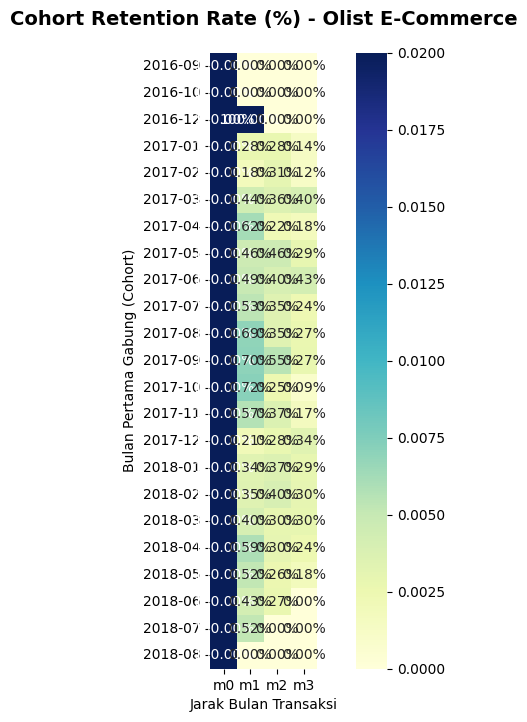

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setelah ditambah 2 baris di atas, silakan jalankan kembali kode heatmap yang tadi:
cohort_pivot = df_cohort_result.set_index('cohort_month')
cohort_percentage = cohort_pivot.divide(cohort_pivot['m0'], axis=0)

plt.figure(figsize=(10, 8))
plt.title('Cohort Retention Rate (%) - Olist E-Commerce', fontsize=14, fontweight='bold', pad=20)

sns.heatmap(data=cohort_percentage,
            annot=True,
            fmt='.2%',
            cmap='YlGnBu',
            vmax=0.02,
            square=True)

plt.ylabel('Bulan Pertama Gabung (Cohort)')
plt.xlabel('Jarak Bulan Transaksi')
plt.show()

In [9]:
# 1. Membaca tabel order items yang berisi harga
order_items = pd.read_csv('olist_order_items_dataset.csv')

# 2. Memasukkan tabel order items ke database SQL kita
order_items.to_sql('order_items_clean', conn, if_exists='replace', index=False)

print("Tabel 'order_items_clean' berhasil masuk ke database. Siap untuk hitung RFM!")

Tabel 'order_items_clean' berhasil masuk ke database. Siap untuk hitung RFM!


In [10]:
query_rfm_base = """
WITH rfm_basic AS (
    SELECT
        o.customer_unique_id,
        -- 1. Mencari tanggal transaksi terakhir tiap user
        MAX(o.order_purchase_timestamp) AS last_transaction,
        -- 2. Menghitung jumlah order unik (Frequency)
        COUNT(DISTINCT o.order_id) AS frequency,
        -- 3. Menghitung total pengeluaran (Monetary)
        SUM(i.price) AS monetary
    FROM orders_clean o
    JOIN order_items_clean i ON o.order_id = i.order_id
    GROUP BY o.customer_unique_id
),

max_date_cte AS (
    -- Mencari tanggal paling terakhir di dataset sebagai titik acuan hitung hari
    SELECT MAX(order_purchase_timestamp) AS max_dataset_date FROM orders_clean
)

SELECT
    r.customer_unique_id,
    -- 4. Menghitung selisih hari (Recency) menggunakan fungsi JULIANDAY di SQLite
    CAST(JULIANDAY((SELECT max_dataset_date FROM max_date_cte)) - JULIANDAY(r.last_transaction) AS INT) AS recency,
    r.frequency,
    ROUND(r.monetary, 2) AS monetary
FROM rfm_basic r
ORDER BY frequency DESC, monetary DESC
LIMIT 10;
"""

# Jalankan query dan tampilkan hasil 10 pelanggan teratas
df_rfm_base = pd.read_sql_query(query_rfm_base, conn)
df_rfm_base

,customer_unique_id,recency,frequency,monetary
0,8d50f5eadf50201ccdcedfb9e2ac8455,8,15,714.63
1,3e43e6105506432c953e165fb2acf44c,182,9,1000.85
2,1b6c7548a2a1f9037c1fd3ddfed95f33,196,7,809.21
3,ca77025e7201e3b30c44b472ff346268,89,7,806.61
4,6469f99c1f9dfae7733b25662e7f1782,62,7,664.20
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,216,6,836.60
6,dc813062e0fc23409cd255f7f53c7074,6,6,687.76
7,63cfc61cee11cbe306bff5857d00bfe4,92,6,579.81
8,f0e310a6839dce9de1638e0fe5ab282a,146,6,438.09
9,12f5d6e1cbf93dafd9dcc19095df0b3d,600,6,58.40


In [11]:
# 1. Ambil seluruh data RFM dasar dari SQL tanpa LIMIT
query_rfm_all = """
WITH rfm_basic AS (
    SELECT
        o.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_transaction,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(i.price) AS monetary
    FROM orders_clean o
    JOIN order_items_clean i ON o.order_id = i.order_id
    GROUP BY o.customer_unique_id
),
max_date_cte AS (
    SELECT MAX(order_purchase_timestamp) AS max_dataset_date FROM orders_clean
)
SELECT
    r.customer_unique_id,
    CAST(JULIANDAY((SELECT max_dataset_date FROM max_date_cte)) - JULIANDAY(r.last_transaction) AS INT) AS recency,
    r.frequency,
    ROUND(r.monetary, 2) AS monetary
FROM rfm_basic r;
"""
df_rfm = pd.read_sql_query(query_rfm_all, conn)

# 2. Memberikan skor 1-5 untuk Recency dan Monetary (Menggunakan qcut)
# Untuk Recency: semakin kecil hari (baru belanja), semakin bagus (skor 5)
df_rfm['R_score'] = pd.qcut(df_rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
# Untuk Monetary: semakin besar uang yang habis, semakin bagus (skor 5)
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Karena mayoritas frequency nilainya 1, kita gunakan fungsi penanda manual saja agar tidak error
df_rfm['F_score'] = df_rfm['frequency'].apply(lambda x: 1 if x == 1 else (3 if x == 2 else 5))

# 3. Membuat Fungsi Segmentasi Sederhana
def tentukan_segmen(row):
    r = int(row['R_score'])
    f = int(row['F_score'])

    if r >= 4 and f >= 3:
        return 'Champions / Loyal'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    elif r <= 2 and f >= 3:
        return "Can't Lose Them"
    elif r >= 4 and f <= 2:
        return 'New Customers'
    else:
        return 'About to Sleep'

# Terapkan fungsi ke dataframe
df_rfm['Segment'] = df_rfm.apply(tentukan_segmen, axis=1)

# 4. Tampilkan total jumlah pelanggan di setiap segmen
print("--- DISTRIBUSI SEGMEN PELANGGAN ---")
print(df_rfm['Segment'].value_counts())

--- DISTRIBUSI SEGMEN PELANGGAN ---
Segment
Lost Customers       36228
New Customers        36224
About to Sleep       18709
Champions / Loyal     1209
Can't Lose Them        988
Name: count, dtype: int64


In [12]:
# Menyimpan hasil RFM ke dalam file CSV
df_rfm.to_csv('olist_rfm_segments.csv', index=False)

print("File 'olist_rfm_segments.csv' siap diunduh di menu folder sebelah kiri!")

File 'olist_rfm_segments.csv' siap diunduh di menu folder sebelah kiri!
